---
# Metody oparte na sąsiedztwie
---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import numpy as np

from ucimlrepo import fetch_ucirepo 
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, ConfusionMatrixDisplay

In [2]:
sklearn.set_config(transform_output="pandas")
sklearn.__version__

'1.8.0'

# Przykład - [Yeast](https://archive.ics.uci.edu/dataset/110/yeast)

Tym razem zajmiemy się problemem klasyfikacji na przykładzie prognozowania miejsc lokalizacji komórkowej białek

## Załadowanie danych

In [3]:
yeast = fetch_ucirepo(id=110) 
X = yeast.data.features 
y = yeast.data.targets 

In [4]:
X.shape, len(y)

((1484, 8), 1484)

## Wstępne przetwarzanie danych

### Brakujące dane

In [5]:
X[pd.isna(X).any(axis=1)]

,mcg,gvh,alm,mit,erl,pox,vac,nuc


### Zmienne katagoryczne

#### Rzadkie kategorie
Niektóre kategorie mają mało przykładów, ale usuńmy tylko skrajną tj. `ERL`

In [6]:
y.value_counts()

localization_site
CYT                  463
NUC                  429
MIT                  244
ME3                  163
ME2                   51
ME1                   44
EXC                   35
VAC                   30
POX                   20
ERL                    5
Name: count, dtype: int64

In [7]:
idx_to_drop = y[y['localization_site'] == 'ERL'].index
X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

<span style="color:red">**Ćwiczenie:**</span> użyj `OrdinalEncoder` do usunięcia rzadkiej kategorii.

#### Kodowanie katagorii
Tym razem używamy [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) a nie `one-hot encoder`!

In [8]:
label_encoder = LabelEncoder()

In [9]:
y_trans = label_encoder.fit_transform(y['localization_site'].values)

### Standardyzacja / normalizacja
Na początek, wybieramy standardowe skalowanie:

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Klasyfikator kNN

### Podział danych na zbiór treningowy i testowy

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_trans, stratify=y_trans,
                                                    test_size=0.1, random_state=0)

<span style="color:red">**Ćwiczenie:**</span> co się stanie, gdy nie podamy parametru `stratify`?

### Dostrajamy model
- Używamy domyślnych hiperparametrów - zawsze warto od nich zacząć
- Zauważmy, że model nie jest formalnie trenowany

In [12]:
knn = KNeighborsClassifier(n_jobs=-1)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


### Sprawdzamy wyniki

In [13]:
y_pred_train = knn.predict(X_train)
y_pred_test  = knn.predict(X_test)

#### f1-score

In [14]:
f1_score(y_train, y_pred_train, average='weighted'), \
f1_score(y_test, y_pred_test, average='weighted')

(0.6700505005259814, 0.5387392349820613)

In [15]:
f1_score(y_train, y_pred_train, average='micro'), \
f1_score(y_test, y_pred_test, average='micro')

(0.6791885800150262, 0.5540540540540541)

In [16]:
f1_score(y_train, y_pred_train, average='macro'), \
f1_score(y_test, y_pred_test, average='macro')

(0.6017077890637409, 0.38479633045630174)

- Wynik na zbiorze treningowym jest poniżej oczekiwań
- Wynik na zbiorze testowym jest wyrażnie gorszy, niż na zbiorze treningowym

#### Macierz pomyłek
Macierz ta pozwala lepiej zrozumieć, z jakimi kategoriami model ma problem

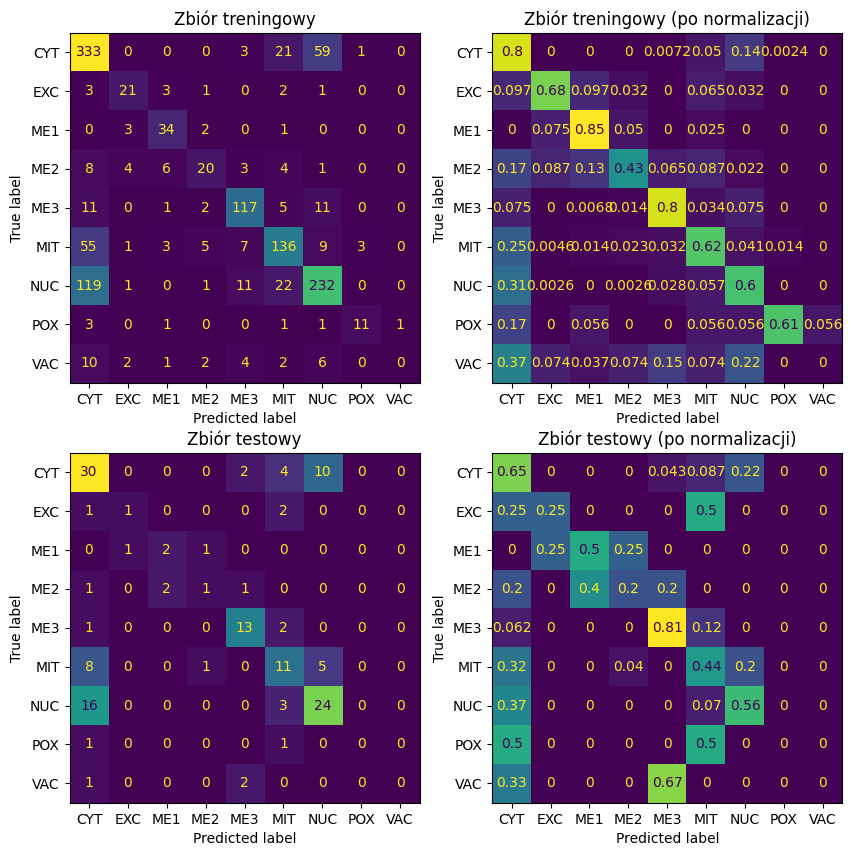

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
kwargs = {'colorbar': None, 'display_labels': label_encoder.classes_}
labels = ['Zbiór treningowy', 'Zbiór testowy']
for i, (y1, y2) in enumerate(zip([y_train, y_test], [y_pred_train, y_pred_test])):
    ConfusionMatrixDisplay.from_predictions(y1, y2, ax=ax[i, 0], **kwargs)
    ConfusionMatrixDisplay.from_predictions(y1, y2, ax=ax[i, 1], normalize="true", **kwargs)
    ax[i, 0].set_title(f"{labels[i]}")
    ax[i, 1].set_title(f"{labels[i]} (po normalizacji)")
plt.show()

- Widać, że mamy poważny problem z klasyfikacją kategorii MIT i NUC
- Mało tego, problem pojawia się już podczas treningu